Import Necessary Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
import numpy as np
import geopandas as gpd
from tqdm import tqdm
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from shapely.ops import nearest_points

## Load Data from V2

In [2]:
cleaned_data = pd.read_csv('data_pre_norm.csv', index_col=0)
cleaned_data.head()

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,Lineament,Right-lateral Fault,Normal Fault,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal)
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.912006,-43.6825,16042.943074,38240.015578,7608.200346,32274.809475,38166.067805,178510.268973,12107.518869,28.0,-54.87500,-107.350006,-155.604003
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.311332,-43.6825,15471.824393,37942.352312,8075.823613,32849.251541,38767.181198,179076.006649,12521.081516,28.0,-54.87500,-107.350006,-155.604003
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.265493,-43.6825,15751.330619,38097.704215,7838.753798,32567.674193,38474.927997,178798.267287,12309.048726,28.0,-54.87500,-107.350006,-155.604003
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.810774,-3.9287,35178.987807,61605.456789,39427.671692,110966.615285,57996.892585,321929.890761,38740.878594,20.0,-0.40625,-26.175018,-58.520164
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.879615,-2.2424,36371.533982,52965.253274,34306.255135,94735.671514,87776.161121,355936.702855,36506.159761,20.0,-3.53125,-27.399994,-55.094943


## Distance to basement (surface), V3

In [3]:
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm

# Convert 'cleaned_data' into a GeoDataFrame with WGS84 coordinates
gdf_cleaned_data = gpd.GeoDataFrame(
    cleaned_data,
    geometry=gpd.points_from_xy(cleaned_data.Longitude, cleaned_data.Latitude),
    crs="EPSG:4326"  # WGS84
)

# Load the 'basement' shapefile
basement = gpd.read_file('data/Geology/Rock_types.shx')

# Filter 'basement' to only include rows where 'classified' equals 1
basement_classified_1 = basement[basement['classified'] == 1]

# Reproject both GeoDataFrames to MAGNA-SIRGAS (EPSG:3116)
gdf_cleaned_data = gdf_cleaned_data.to_crs("EPSG:3116")
basement_classified_1 = basement_classified_1.to_crs("EPSG:3116")

# Initialize a column for the distances
cleaned_data['Nearest Basement'] = np.nan

# Calculate the distance from each point in 'gdf_cleaned_data' to the nearest '1' in 'basement_classified_1'
for index, row in tqdm(gdf_cleaned_data.iterrows(), total=gdf_cleaned_data.shape[0], desc="Calculating distances"):
    # Calculate the distance to the nearest point in 'basement_classified_1' and update the 'distance_to_1' column
    cleaned_data.at[index, 'Nearest Basement'] = basement_classified_1.distance(row.geometry).min()

Calculating distances: 100%|██████████| 4543/4543 [00:56<00:00, 80.12it/s]


In [4]:
cleaned_data

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,Lineament,Right-lateral Fault,Normal Fault,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.912006,-43.6825,16042.943074,38240.015578,7608.200346,32274.809475,38166.067805,178510.268973,12107.518869,28.0,-54.87500,-107.350006,-155.604003,26430.359640
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.311332,-43.6825,15471.824393,37942.352312,8075.823613,32849.251541,38767.181198,179076.006649,12521.081516,28.0,-54.87500,-107.350006,-155.604003,26807.505168
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.265493,-43.6825,15751.330619,38097.704215,7838.753798,32567.674193,38474.927997,178798.267287,12309.048726,28.0,-54.87500,-107.350006,-155.604003,26613.393422
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.810774,-3.9287,35178.987807,61605.456789,39427.671692,110966.615285,57996.892585,321929.890761,38740.878594,20.0,-0.40625,-26.175018,-58.520164,43126.506306
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.879615,-2.2424,36371.533982,52965.253274,34306.255135,94735.671514,87776.161121,355936.702855,36506.159761,20.0,-3.53125,-27.399994,-55.094943,43893.018161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,9.198753,-74.545831,14.9352,28.125324,22.902864,37255.351981,-29.3196,67951.218564,84851.479187,56595.020520,88505.305904,64495.836547,259372.804468,80852.179701,20.0,-0.53125,-40.925020,-39.287390,40390.065825
4539,9.193783,-74.545203,17.6784,28.111608,23.599190,37242.152495,-29.3196,67503.732300,84298.012717,56071.263149,87971.739857,64199.313789,258821.634484,80298.996774,20.0,-0.53125,-40.925020,-39.287390,39863.481446
4540,9.210378,-74.266786,21.3360,28.093320,22.529272,37076.390931,-59.0881,49589.080907,56467.948967,52443.767658,83005.223439,40008.137041,255540.784076,69911.233325,24.0,-12.87500,-40.475006,-37.082959,32815.518722
4541,8.213381,-72.470731,86.8680,27.765660,23.098588,36883.953489,21.7434,9812.610984,94782.592997,11630.076088,196307.990555,38178.497828,223384.739466,5879.044197,32.0,-40.43750,-87.850006,-103.230325,31514.418056


## Volcanic domain weights

In [5]:
from geopy.distance import great_circle

# Load the volcanic zone locations
volcanic_zones_df = pd.read_csv('data/Volcanes_col.csv')
# Convert to a GeoDataFrame
gdf_volcanic_zones = gpd.GeoDataFrame(
    volcanic_zones_df,
    geometry=gpd.points_from_xy(volcanic_zones_df.X, volcanic_zones_df.Y),
    crs='EPSG:4326'  # assuming the coordinates are in WGS84
)

gdf_volcanic_zones = gdf_volcanic_zones.to_crs('EPSG:3116')
gdf_cleaned_data = gdf_cleaned_data.to_crs('EPSG:3116')

# Redefine the calculate_distance_to_volcano function
def calculate_distance_to_volcano(row, volcanic_zones):
    distances = volcanic_zones.distance(row.geometry)
    return distances.min()

# Use tqdm to show a progress bar
tqdm.pandas(desc="Calculating distances to nearest volcano")
cleaned_data['Nearest Volcano'] = gdf_cleaned_data.progress_apply(
    lambda row: calculate_distance_to_volcano(row, gdf_volcanic_zones['geometry']),
    axis=1
)

# Define a threshold for proximity to volcanic zones
volcanic_proximity_threshold = 50000  # 50 km

# Flag wells as near or not near a volcano
cleaned_data['Volcanic domain'] = cleaned_data['Nearest Volcano'] < volcanic_proximity_threshold

Calculating distances to nearest volcano: 100%|██████████| 4543/4543 [00:00<00:00, 9516.62it/s]


In [6]:
cleaned_data

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Right-lateral Fault,Normal Fault,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.912006,-43.6825,16042.943074,38240.015578,7608.200346,...,38166.067805,178510.268973,12107.518869,28.0,-54.87500,-107.350006,-155.604003,26430.359640,37574.493842,True
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.311332,-43.6825,15471.824393,37942.352312,8075.823613,...,38767.181198,179076.006649,12521.081516,28.0,-54.87500,-107.350006,-155.604003,26807.505168,37828.184637,True
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.265493,-43.6825,15751.330619,38097.704215,7838.753798,...,38474.927997,178798.267287,12309.048726,28.0,-54.87500,-107.350006,-155.604003,26613.393422,37691.342706,True
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.810774,-3.9287,35178.987807,61605.456789,39427.671692,...,57996.892585,321929.890761,38740.878594,20.0,-0.40625,-26.175018,-58.520164,43126.506306,74754.728085,False
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.879615,-2.2424,36371.533982,52965.253274,34306.255135,...,87776.161121,355936.702855,36506.159761,20.0,-3.53125,-27.399994,-55.094943,43893.018161,84568.777113,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,9.198753,-74.545831,14.9352,28.125324,22.902864,37255.351981,-29.3196,67951.218564,84851.479187,56595.020520,...,64495.836547,259372.804468,80852.179701,20.0,-0.53125,-40.925020,-39.287390,40390.065825,395256.804800,False
4539,9.193783,-74.545203,17.6784,28.111608,23.599190,37242.152495,-29.3196,67503.732300,84298.012717,56071.263149,...,64199.313789,258821.634484,80298.996774,20.0,-0.53125,-40.925020,-39.287390,39863.481446,394718.812048,False
4540,9.210378,-74.266786,21.3360,28.093320,22.529272,37076.390931,-59.0881,49589.080907,56467.948967,52443.767658,...,40008.137041,255540.784076,69911.233325,24.0,-12.87500,-40.475006,-37.082959,32815.518722,401244.977788,False
4541,8.213381,-72.470731,86.8680,27.765660,23.098588,36883.953489,21.7434,9812.610984,94782.592997,11630.076088,...,38178.497828,223384.739466,5879.044197,32.0,-40.43750,-87.850006,-103.230325,31514.418056,395121.959675,False


### Assign sample weights based on proximity to a volcano

In [7]:
cleaned_data['Volcanic weight'] = cleaned_data['Volcanic domain'].apply(lambda x: 4 if not x else 1)

In [8]:
cleaned_data

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Normal Fault,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight
0,4.213002,-74.893581,313.9440,26.630280,14.712281,42863.912006,-43.6825,16042.943074,38240.015578,7608.200346,...,178510.268973,12107.518869,28.0,-54.87500,-107.350006,-155.604003,26430.359640,37574.493842,True,1
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.311332,-43.6825,15471.824393,37942.352312,8075.823613,...,179076.006649,12521.081516,28.0,-54.87500,-107.350006,-155.604003,26807.505168,37828.184637,True,1
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.265493,-43.6825,15751.330619,38097.704215,7838.753798,...,178798.267287,12309.048726,28.0,-54.87500,-107.350006,-155.604003,26613.393422,37691.342706,True,1
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.810774,-3.9287,35178.987807,61605.456789,39427.671692,...,321929.890761,38740.878594,20.0,-0.40625,-26.175018,-58.520164,43126.506306,74754.728085,False,4
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.879615,-2.2424,36371.533982,52965.253274,34306.255135,...,355936.702855,36506.159761,20.0,-3.53125,-27.399994,-55.094943,43893.018161,84568.777113,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,9.198753,-74.545831,14.9352,28.125324,22.902864,37255.351981,-29.3196,67951.218564,84851.479187,56595.020520,...,259372.804468,80852.179701,20.0,-0.53125,-40.925020,-39.287390,40390.065825,395256.804800,False,4
4539,9.193783,-74.545203,17.6784,28.111608,23.599190,37242.152495,-29.3196,67503.732300,84298.012717,56071.263149,...,258821.634484,80298.996774,20.0,-0.53125,-40.925020,-39.287390,39863.481446,394718.812048,False,4
4540,9.210378,-74.266786,21.3360,28.093320,22.529272,37076.390931,-59.0881,49589.080907,56467.948967,52443.767658,...,255540.784076,69911.233325,24.0,-12.87500,-40.475006,-37.082959,32815.518722,401244.977788,False,4
4541,8.213381,-72.470731,86.8680,27.765660,23.098588,36883.953489,21.7434,9812.610984,94782.592997,11630.076088,...,223384.739466,5879.044197,32.0,-40.43750,-87.850006,-103.230325,31514.418056,395121.959675,False,4


## Handling under and over represented gradients data

In [9]:
extreme_gradient_threshold = cleaned_data['Apparent Geothermal Gradient (°C/Km)'].quantile(0.99)
print(f"Extreme gradient threshold (99th percentile): {extreme_gradient_threshold}")

Extreme gradient threshold (99th percentile): 43.80890461174968


In [10]:
lowest_gradient_threshold = cleaned_data['Apparent Geothermal Gradient (°C/Km)'].quantile(0.01)
print(f"Lowest gradient threshold (01st percentile): {lowest_gradient_threshold}")

Lowest gradient threshold (01st percentile): 14.87317986940993


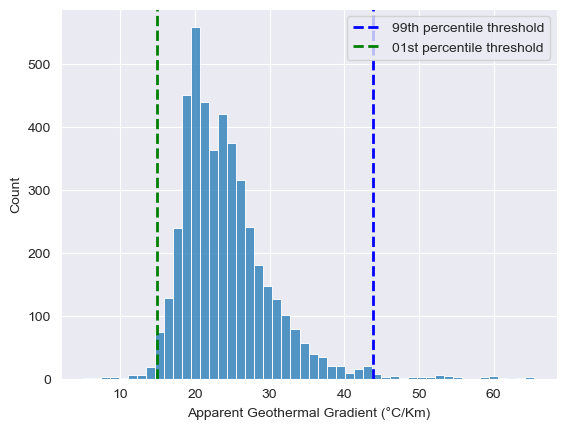

In [11]:
sns.histplot(cleaned_data['Apparent Geothermal Gradient (°C/Km)'], kde=False, bins=50)
plt.axvline(extreme_gradient_threshold, color='blue', linestyle='--', linewidth=2, label='99th percentile threshold')
plt.axvline(lowest_gradient_threshold, color='green', linestyle='--', linewidth=2, label='01st percentile threshold')
plt.legend()
plt.show()

In [12]:
cleaned_data = cleaned_data[cleaned_data['Apparent Geothermal Gradient (°C/Km)'] <= extreme_gradient_threshold]
cleaned_data = cleaned_data[cleaned_data['Apparent Geothermal Gradient (°C/Km)'] >= lowest_gradient_threshold]

<Axes: xlabel='Apparent Geothermal Gradient (°C/Km)', ylabel='Count'>

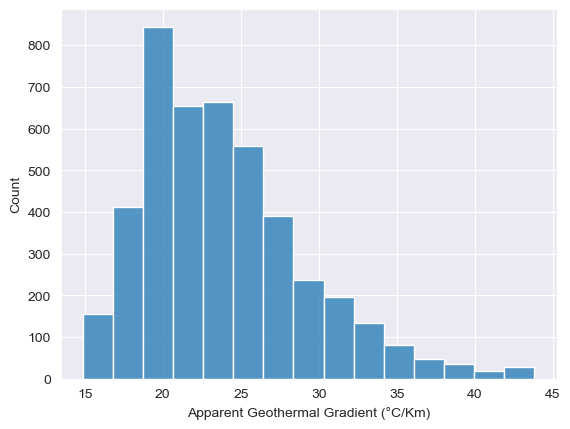

In [13]:
sns.histplot(cleaned_data['Apparent Geothermal Gradient (°C/Km)'], kde=False, bins=15)

In [14]:
# Define bin edges and assign each gradient value to a bin
bins = np.linspace(cleaned_data['Apparent Geothermal Gradient (°C/Km)'].min(), 
                   cleaned_data['Apparent Geothermal Gradient (°C/Km)'].max(), 
                   num=16)  # 50 bins + 1 for the edge
cleaned_data['Gradient Bin'] = np.digitize(cleaned_data['Apparent Geothermal Gradient (°C/Km)'], bins)

# Calculate the frequency of each bin
bin_counts = cleaned_data['Gradient Bin'].value_counts()

# Calculate the raw weights
raw_weights = (1 / (bin_counts + 0.00001))

# Normalize the raw weights so the smallest weight (most frequent bin) is 1
normalized_weights = raw_weights / raw_weights.min()

# Now clip the maximum weight to 50
clipped_weights = np.clip(normalized_weights, 1, 50)

# Map the clipped weights back to the dataframe
cleaned_data['Gradient Weight'] = cleaned_data['Gradient Bin'].map(clipped_weights)

# Normalize the weights again to have the maximum as 1
cleaned_data['Gradient Weight'] = cleaned_data['Gradient Weight'] / cleaned_data['Gradient Weight'].max()

# Drop the 'Gradient Bin' column if it's no longer needed
cleaned_data.drop('Gradient Bin', axis=1, inplace=True)

In [15]:
cleaned_data

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Active Fault,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,Gradient Weight
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.311332,-43.6825,15471.824393,37942.352312,8075.823613,...,12521.081516,28.0,-54.87500,-107.350006,-155.604003,26807.505168,37828.184637,True,1,0.025810
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.265493,-43.6825,15751.330619,38097.704215,7838.753798,...,12309.048726,28.0,-54.87500,-107.350006,-155.604003,26613.393422,37691.342706,True,1,0.025460
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.810774,-3.9287,35178.987807,61605.456789,39427.671692,...,38740.878594,20.0,-0.40625,-26.175018,-58.520164,43126.506306,74754.728085,False,4,0.025460
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.879615,-2.2424,36371.533982,52965.253274,34306.255135,...,36506.159761,20.0,-3.53125,-27.399994,-55.094943,43893.018161,84568.777113,False,4,0.030197
5,0.287539,-76.911964,297.4848,26.712576,26.559722,37704.400313,-2.2424,37519.198283,54966.653565,35746.349888,...,36131.515809,20.0,-3.53125,-11.125000,-50.959084,45088.511661,86366.785176,False,4,0.043282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,9.198753,-74.545831,14.9352,28.125324,22.902864,37255.351981,-29.3196,67951.218564,84851.479187,56595.020520,...,80852.179701,20.0,-0.53125,-40.925020,-39.287390,40390.065825,395256.804800,False,4,0.025460
4539,9.193783,-74.545203,17.6784,28.111608,23.599190,37242.152495,-29.3196,67503.732300,84298.012717,56071.263149,...,80298.996774,20.0,-0.53125,-40.925020,-39.287390,39863.481446,394718.812048,False,4,0.025460
4540,9.210378,-74.266786,21.3360,28.093320,22.529272,37076.390931,-59.0881,49589.080907,56467.948967,52443.767658,...,69911.233325,24.0,-12.87500,-40.475006,-37.082959,32815.518722,401244.977788,False,4,0.025810
4541,8.213381,-72.470731,86.8680,27.765660,23.098588,36883.953489,21.7434,9812.610984,94782.592997,11630.076088,...,5879.044197,32.0,-40.43750,-87.850006,-103.230325,31514.418056,395121.959675,False,4,0.025460


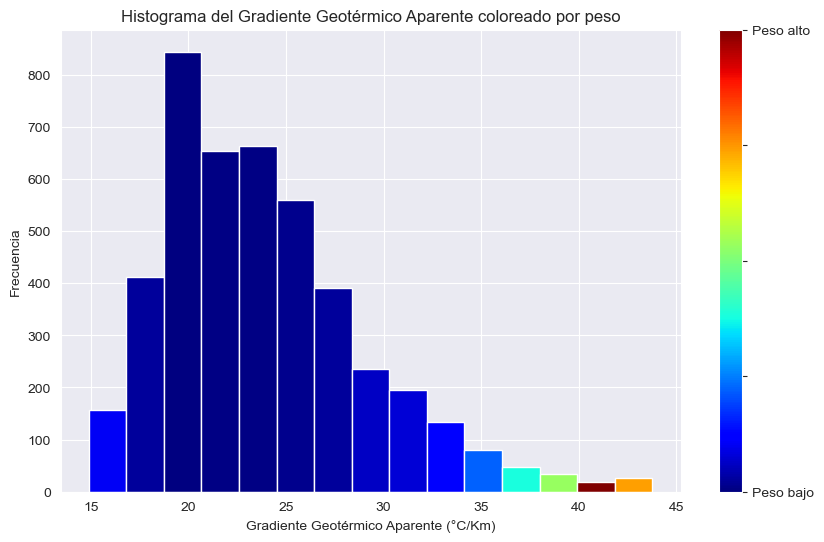

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd  # Asegúrate de tener pandas importado

# Crear los bordes de los bins del histograma
bin_edges = np.linspace(
    cleaned_data['Apparent Geothermal Gradient (°C/Km)'].min(),
    cleaned_data['Apparent Geothermal Gradient (°C/Km)'].max(),
    num=16  # número de bordes -> crea num-1 bins
)

# Asignar cada valor a su bin correspondiente
cleaned_data['bin'] = np.digitize(
    cleaned_data['Apparent Geothermal Gradient (°C/Km)'],
    bins=bin_edges,
    right=True
)

# Calcular el peso medio por bin
bin_to_weight = cleaned_data.groupby('bin')['Gradient Weight'].mean()

# Asegurar que todos los bins existen (aunque estén vacíos)
num_bins = len(bin_edges) - 1
all_bins = range(1, num_bins + 1)
bin_to_weight_full = bin_to_weight.reindex(all_bins).fillna(0.0)  # puedes cambiar a np.nan si lo prefieres

# Normalizar los pesos a [0, 1]
w_min = bin_to_weight_full.min()
w_max = bin_to_weight_full.max()
if w_max > w_min:
    bin_weights_norm = (bin_to_weight_full - w_min) / (w_max - w_min)
else:
    # Si todos los valores son iguales, usa un valor medio (0.5)
    bin_weights_norm = pd.Series(0.5, index=bin_to_weight_full.index)

# Crear figura y ejes explícitamente
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar el histograma
n, bins, patches = ax.hist(
    cleaned_data['Apparent Geothermal Gradient (°C/Km)'],
    bins=bin_edges,
    color='blue'  # color base que será reemplazado
)

# Definir el colormap y normalización
cmap = plt.cm.jet
norm = mcolors.Normalize(vmin=bin_weights_norm.min(), vmax=bin_weights_norm.max())

# Colorear cada bin según su peso normalizado
for i, patch in enumerate(patches):  # i va de 0 a num_bins-1
    bin_number = i + 1               # porque digitize usa índices desde 1
    color = cmap(norm(bin_weights_norm.loc[bin_number]))
    patch.set_facecolor(color)

# Eliminar la columna temporal 'bin'
cleaned_data.drop('bin', axis=1, inplace=True)

# Etiquetas y título
ax.set_xlabel('Gradiente Geotérmico Aparente (°C/Km)')
ax.set_ylabel('Frecuencia')
ax.set_title('Histograma del Gradiente Geotérmico Aparente coloreado por peso')

# Crear el objeto ScalarMappable para la barra de color
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(bin_weights_norm.values)

# Añadir la barra de color al gráfico
cbar = fig.colorbar(sm, ax=ax, ticks=np.linspace(bin_weights_norm.min(), bin_weights_norm.max(), num=5))
cbar.ax.set_yticklabels(['Peso bajo', '', '', '', 'Peso alto'])

plt.show()


## Multiply the volcanic weights by the high gradient weights to get the final sample weights

In [17]:
cleaned_data['sample_weight'] = cleaned_data['Volcanic weight'] * cleaned_data['Gradient Weight']

In [18]:
weights = cleaned_data['sample_weight']

## Save dataset with weights

In [19]:
cleaned_data.to_csv('data_weights.csv')

In [20]:
cleaned_data = pd.read_csv('data_weights.csv', index_col=0)
cleaned_data

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,Gradient Weight,sample_weight
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.311332,-43.6825,15471.824393,37942.352312,8075.823613,...,28.0,-54.87500,-107.350006,-155.604003,26807.505168,37828.184637,True,1,0.025810,0.025810
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.265493,-43.6825,15751.330619,38097.704215,7838.753798,...,28.0,-54.87500,-107.350006,-155.604003,26613.393422,37691.342706,True,1,0.025460,0.025460
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.810774,-3.9287,35178.987807,61605.456789,39427.671692,...,20.0,-0.40625,-26.175018,-58.520164,43126.506306,74754.728085,False,4,0.025460,0.101840
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.879615,-2.2424,36371.533982,52965.253274,34306.255135,...,20.0,-3.53125,-27.399994,-55.094943,43893.018161,84568.777113,False,4,0.030197,0.120787
5,0.287539,-76.911964,297.4848,26.712576,26.559722,37704.400313,-2.2424,37519.198283,54966.653565,35746.349888,...,20.0,-3.53125,-11.125000,-50.959084,45088.511661,86366.785176,False,4,0.043282,0.173128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538,9.198753,-74.545831,14.9352,28.125324,22.902864,37255.351981,-29.3196,67951.218564,84851.479187,56595.020520,...,20.0,-0.53125,-40.925020,-39.287390,40390.065825,395256.804800,False,4,0.025460,0.101840
4539,9.193783,-74.545203,17.6784,28.111608,23.599190,37242.152495,-29.3196,67503.732300,84298.012717,56071.263149,...,20.0,-0.53125,-40.925020,-39.287390,39863.481446,394718.812048,False,4,0.025460,0.101840
4540,9.210378,-74.266786,21.3360,28.093320,22.529272,37076.390931,-59.0881,49589.080907,56467.948967,52443.767658,...,24.0,-12.87500,-40.475006,-37.082959,32815.518722,401244.977788,False,4,0.025810,0.103242
4541,8.213381,-72.470731,86.8680,27.765660,23.098588,36883.953489,21.7434,9812.610984,94782.592997,11630.076088,...,32.0,-40.43750,-87.850006,-103.230325,31514.418056,395121.959675,False,4,0.025460,0.101840


## Normalization of the data

Input data needs to be normalized as the features are in different scales. Target (heat flow) is not being normalized.

In [21]:
from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = ['Elevation (m)', 'Surface Temperature (°C)',
       'Moho Depth (m)', 'Curie Depth (Km)', 'Fault', 'Strike-slip Fault',
       'Reverse or Thrust Fault', 'Lineament', 'Right-lateral Fault',
       'Normal Fault', 'Active Fault', 'Nearest Basement', 'Nearest Volcano',
       'Magnetic Anomaly (nT)', 'Vertical Gravity Gradient (E)', 
       'Free Air Anomaly (mGal)','Bouguer Anomaly (mGal)']

# Initialize the Min-Max scaler
scaler = MinMaxScaler()

# Fit and transform the selected columns
cleaned_data[columns_to_normalize] = scaler.fit_transform(cleaned_data[columns_to_normalize])

# Save the normalized data to a new CSV file
cleaned_data.to_csv('normalized_data_minmax.csv', index=False)

In [22]:
cleaned_data.head()

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,Gradient Weight,sample_weight
1,4.216078,-74.888898,0.100557,0.899443,21.294394,0.720455,0.359897,0.053527,0.102362,0.022877,...,0.642857,0.341539,0.096100,0.241172,0.107926,0.034629,True,1,0.025810,0.025810
2,4.214720,-74.891220,0.101535,0.898465,23.783404,0.720641,0.359897,0.054497,0.102794,0.022201,...,0.642857,0.341539,0.096100,0.241172,0.107145,0.034457,True,1,0.025460,0.025460
3,0.606276,-76.564731,0.088329,0.911671,24.156323,0.412171,0.515283,0.121886,0.168226,0.112310,...,0.357143,0.467743,0.319461,0.615321,0.173626,0.081206,False,4,0.025460,0.101840
4,0.305911,-76.914853,0.029052,0.970948,25.601245,0.483869,0.521874,0.126023,0.144177,0.097701,...,0.357143,0.460502,0.316090,0.628522,0.176712,0.093585,False,4,0.030197,0.120787
5,0.287539,-76.911964,0.095470,0.904530,26.559722,0.477817,0.521874,0.130004,0.149747,0.101809,...,0.357143,0.460502,0.360872,0.644461,0.181525,0.095853,False,4,0.043282,0.173128


## Read the normalized dataset

In [23]:
cleaned_data = pd.read_csv('normalized_data_minmax.csv')
cleaned_data.head()

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,Gradient Weight,sample_weight
0,4.216078,-74.888898,0.100557,0.899443,21.294394,0.720455,0.359897,0.053527,0.102362,0.022877,...,0.642857,0.341539,0.096100,0.241172,0.107926,0.034629,True,1,0.025810,0.025810
1,4.214720,-74.891220,0.101535,0.898465,23.783404,0.720641,0.359897,0.054497,0.102794,0.022201,...,0.642857,0.341539,0.096100,0.241172,0.107145,0.034457,True,1,0.025460,0.025460
2,0.606276,-76.564731,0.088329,0.911671,24.156323,0.412171,0.515283,0.121886,0.168226,0.112310,...,0.357143,0.467743,0.319461,0.615321,0.173626,0.081206,False,4,0.025460,0.101840
3,0.305911,-76.914853,0.029052,0.970948,25.601245,0.483869,0.521874,0.126023,0.144177,0.097701,...,0.357143,0.460502,0.316090,0.628522,0.176712,0.093585,False,4,0.030197,0.120787
4,0.287539,-76.911964,0.095470,0.904530,26.559722,0.477817,0.521874,0.130004,0.149747,0.101809,...,0.357143,0.460502,0.360872,0.644461,0.181525,0.095853,False,4,0.043282,0.173128


## Correlation Matrix

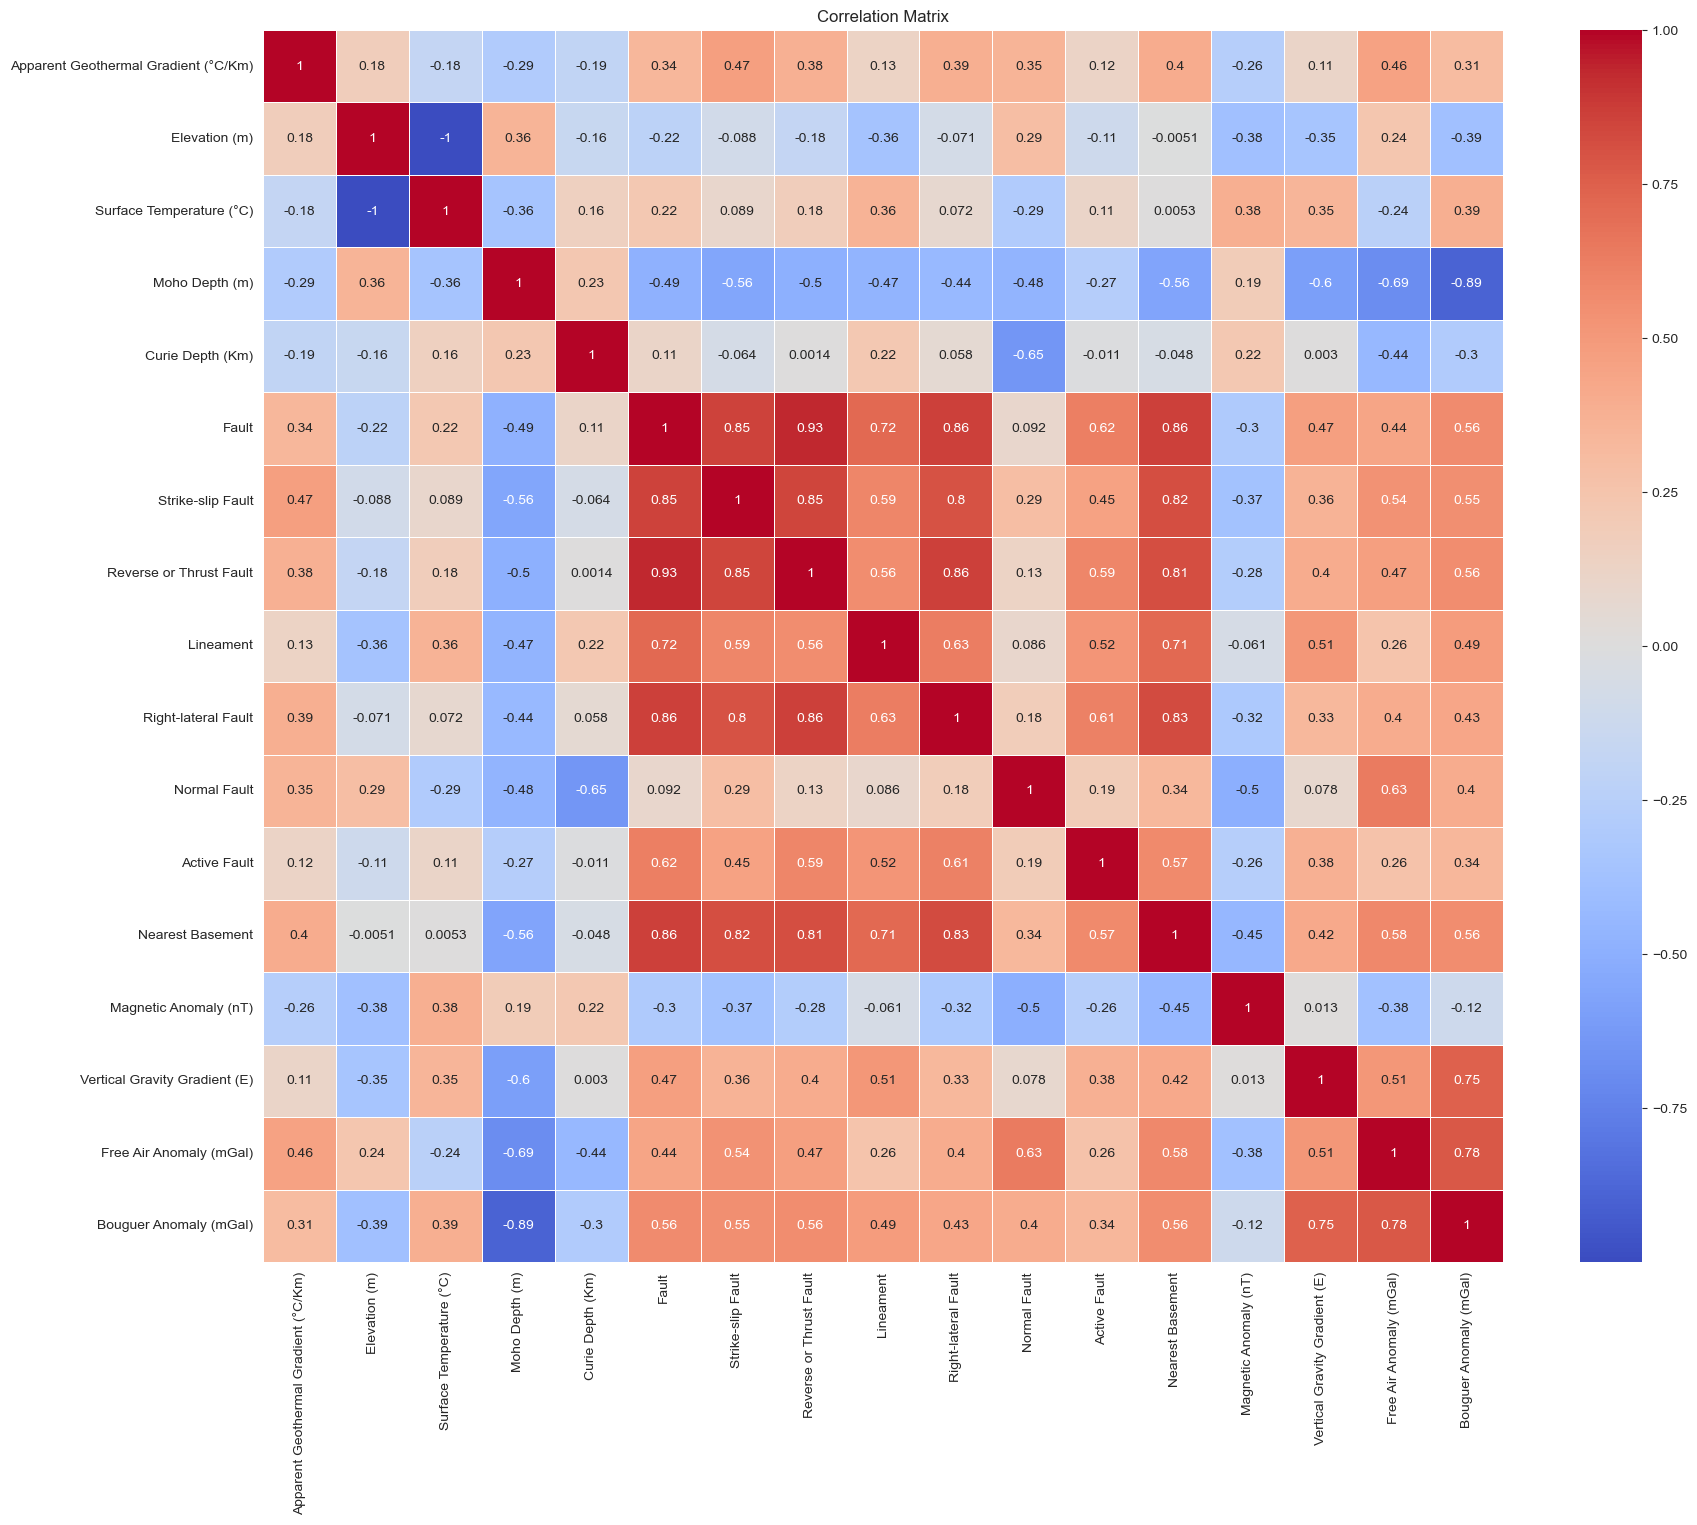

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the desired columns
selected_columns = ['Apparent Geothermal Gradient (°C/Km)', 
       'Elevation (m)', 'Surface Temperature (°C)',
       'Moho Depth (m)', 'Curie Depth (Km)', 'Fault', 'Strike-slip Fault',
       'Reverse or Thrust Fault', 'Lineament', 'Right-lateral Fault',
       'Normal Fault', 'Active Fault', 'Nearest Basement', 
       'Magnetic Anomaly (nT)', 'Vertical Gravity Gradient (E)', 
       'Free Air Anomaly (mGal)','Bouguer Anomaly (mGal)']

# Create a DataFrame with the selected columns
selected_data = cleaned_data[selected_columns]

# Calculate the correlation matrix
correlation_matrix = selected_data.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()


# Building Machine Learning Algorithm

## Data Splitting

In [25]:
cleaned_data.columns

Index(['Latitude', 'Longitude', 'Elevation (m)', 'Surface Temperature (°C)',
       'Apparent Geothermal Gradient (°C/Km)', 'Moho Depth (m)',
       'Magnetic Anomaly (nT)', 'Fault', 'Strike-slip Fault',
       'Reverse or Thrust Fault', 'Lineament', 'Right-lateral Fault',
       'Normal Fault', 'Active Fault', 'Curie Depth (Km)',
       'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)',
       'Bouguer Anomaly (mGal)', 'Nearest Basement', 'Nearest Volcano',
       'Volcanic domain', 'Volcanic weight', 'Gradient Weight',
       'sample_weight'],
      dtype='object')

In [26]:
# Reduce the importance of the free air anomaly
cleaned_data['Free Air Anomaly (mGal)'] = cleaned_data['Free Air Anomaly (mGal)'] * 0.25

In [27]:
# Define feature matrix (X) and target variables (y)
X = cleaned_data[['Latitude', 'Longitude', 'Elevation (m)',
       'Curie Depth (Km)','Moho Depth (m)', 
       'Strike-slip Fault', 'Reverse or Thrust Fault', 
       'Right-lateral Fault', 'Nearest Basement',
       'Normal Fault', 'Active Fault','Magnetic Anomaly (nT)',
       'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)',
       'Bouguer Anomaly (mGal)']]

y = cleaned_data['Apparent Geothermal Gradient (°C/Km)']

# Split the data into a training set and a test set
X_train, X_test, y_train, y_test, weights_train, _ = train_test_split(X, y, weights, test_size=0.2)

# Save X_test with lat and lon for plotting later
X_test_with_lat_lon = X_test[['Latitude', 'Longitude']].copy()

# Save X with lat and lon for plotting later
X_lat_lon = X[['Latitude', 'Longitude']].copy()

# Remove lat and lon from X to predict on the whole dataset
X = X.drop(['Latitude', 'Longitude'], axis=1)

#Remove lat and lon from X_train and X_test
X_train = X_train.drop(['Latitude', 'Longitude'], axis=1)
X_test = X_test.drop(['Latitude', 'Longitude'], axis=1)

## Hyperparameter Tuning

Manually iterating over hyperparameter combinations and recording the progress using the tqdm library. 

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import numpy as np

# Grilla de hiperparámetros para Random Forest
param_grid = {
    'n_estimators': [100, 200, 300, 500],  # número de árboles
    'max_depth': [10, 12, 14, 16, 18, 20],  # límite de profundidad
    'min_samples_split': [2, 4, 6, 8, 10],  # mínimo para dividir
    'min_samples_leaf': [1, 2, 3, 4],  # mínimo por hoja
    'max_features': ['sqrt', 'log2'],  # número de variables usadas
    'bootstrap': [True],  # muestreo con reemplazo
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']
}

best_params = {}
best_mse = float('inf')
best_r2 = -np.inf

total_combinations = len(list(ParameterGrid(param_grid)))
with tqdm(total=total_combinations, desc="Tuning Random Forest") as pbar:
    for params in ParameterGrid(param_grid):

        rf_model = RandomForestRegressor(
            random_state=42,
            n_jobs=4,
            **params
        )

        rf_model.fit(X_train, y_train, sample_weight=weights_train)
        y_pred = rf_model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        if r2 > best_r2:
            best_r2 = r2
            best_mse = mse
            best_params = params

        pbar.update(1)

print("Mejores hiperparámetros:", best_params)
print("MSE:", best_mse)
print("R²:", best_r2)


Tuning Random Forest: 100%|██████████| 3840/3840 [3:24:04<00:00,  3.19s/it]  

Mejores hiperparámetros: {'bootstrap': True, 'criterion': 'friedman_mse', 'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
MSE: 12.997625016800484
R²: 0.5582993803950038


In [29]:
#best_params = {'colsample_bytree': 0.5, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_weight': 1, 'reg_alpha': 0.5, 'reg_lambda': 2, 'subsample': 0.6}

## Train Decision Tree and evaluate model

In [30]:
best_tree_model = RandomForestRegressor(**best_params, random_state=42)
best_tree_model.fit(X_train, y_train, sample_weight=weights_train)

,n_estimators,200
,criterion,'friedman_mse'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
import joblib
joblib.dump(best_tree_model, 'trained_model_randforest_v3.pkl')

['trained_model_randforest_v3.pkl']

In [32]:
import joblib
best_tree_model = joblib.load('trained_model_randforest_v3.pkl')

Evaluate the model's performance on the test data using appropriate regression metrics (e.g., MAE, RMSE, R-squared).

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions on the training set
y_train_pred = best_tree_model.predict(X_train)

# Metrics for the training set
mae_train = mean_absolute_error(y_train, y_train_pred)
#rmse_train = mean_squared_error(y_train, y_train_pred, squared=False)
r2_train = r2_score(y_train, y_train_pred)

print("Training Set Metrics:")
print(f"MAE: {mae_train}")
#print(f"RMSE: {rmse_train}")
print(f"R-squared: {r2_train}")

Training Set Metrics:
MAE: 1.4754631017553292
R-squared: 0.8528693347458238


In [34]:
# Predictions on the test set
y_test_pred = best_tree_model.predict(X_test)

# Metrics for the test set
mae_test = mean_absolute_error(y_test, y_test_pred)
#rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
r2_test = r2_score(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"MAE: {mae_test}")
#print(f"RMSE: {rmse_test}")
print(f"R-squared: {r2_test}")


Test Set Metrics:
MAE: 2.5550595313300586
R-squared: 0.5582993803950038


# Visualization of results

In [35]:
y_pred = y_test_pred

## Residual Plot

Create a residual plot to check if the model's predictions have a pattern. Most residuals must be near to zero

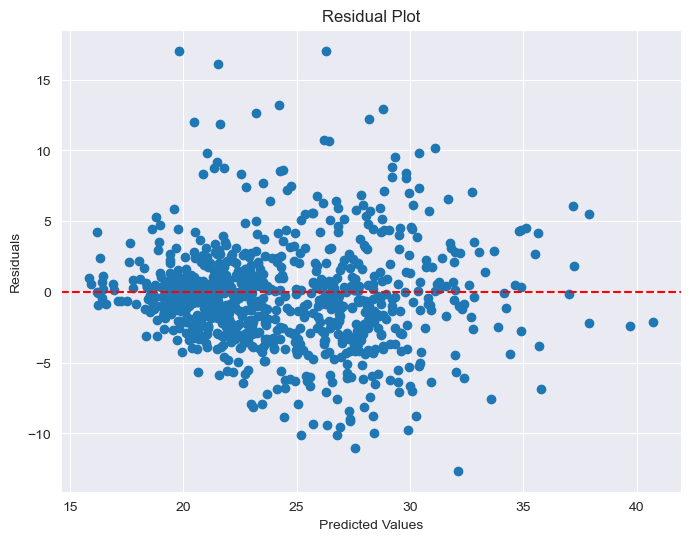

In [36]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.show()

## Actual vs. Predicted Plot

Visualize how model's predictions compare to the actual values.

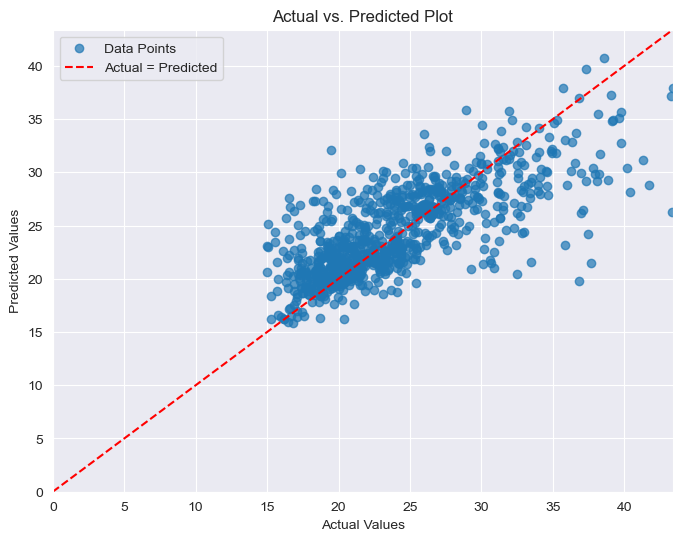

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, label='Data Points', alpha=0.7)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Plot')

# Set x and y axis limits to start at 0,0
plot_max = max(max(y_test), max(y_pred))
plt.xlim(0, plot_max)
plt.ylim(0, plot_max)

# Plot the line where Actual = Predicted
plt.plot([0, plot_max], [0, plot_max], color='red', linestyle='--', label='Actual = Predicted')

plt.legend()
plt.show()

## Feature Importance Plot

Visualize the importance of each feature in the Random Forest model. This will help to understand which features have the most significant impact on predicting the geothermal gradient.

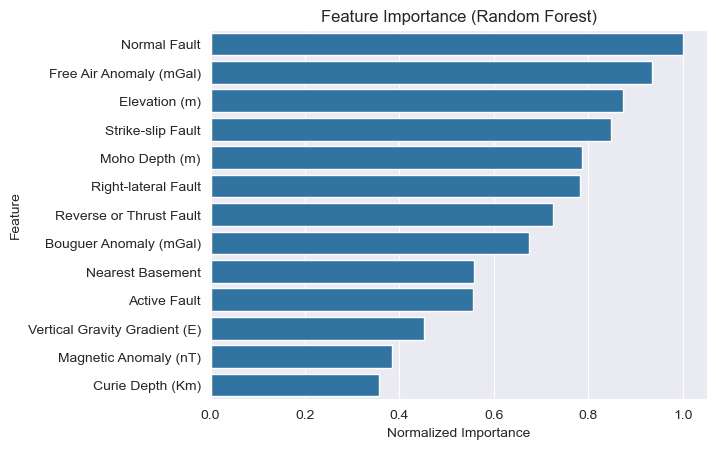

In [40]:
# Importancia directamente desde RF
importance = best_tree_model.feature_importances_

# Normalización (como hacías con XGBoost)
importance_norm = importance / np.max(importance)

# Empaquetar en diccionario: nombre → importancia
importance_dict = dict(zip(X_train.columns, importance_norm))

# Ordenar de mayor a menor
importance_dict = dict(sorted(importance_dict.items(), key=lambda item: item[1], reverse=True))

# Gráfica
sns.barplot(
    x=list(importance_dict.values()),
    y=list(importance_dict.keys())
)

plt.title('Feature Importance (Random Forest)')
plt.xlabel('Normalized Importance')
plt.ylabel('Feature')
plt.show()


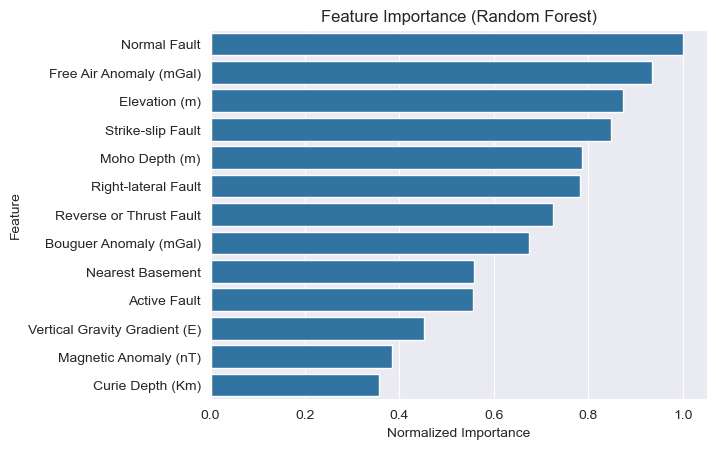

In [41]:
importance = best_tree_model.feature_importances_
importance_norm = importance / np.max(importance)

importance_dict = dict(zip(X_train.columns, importance_norm))
importance_dict = dict(sorted(importance_dict.items(), key=lambda x: x[1], reverse=True))

sns.barplot(x=list(importance_dict.values()), y=list(importance_dict.keys()))
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Normalized Importance')
plt.ylabel('Feature')
plt.show()

## RFE Importance

In [42]:
from xgboost import plot_importance
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
from sklearn.feature_selection import mutual_info_regression

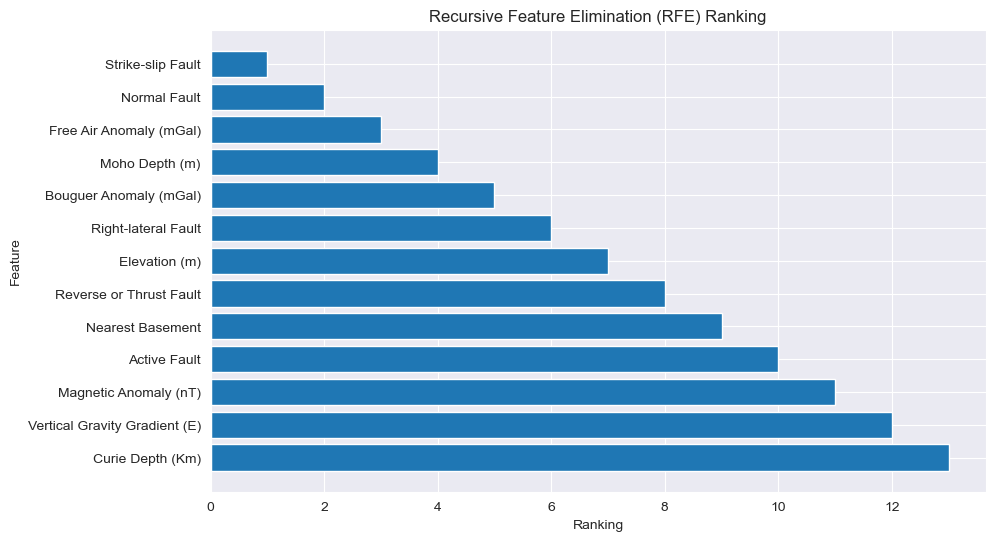

In [43]:
# Recursive Feature Elimination (RFE)
selector = RFE(best_tree_model, n_features_to_select=1)
selector = selector.fit(X_train, y_train)
feature_ranking = selector.ranking_

# Get the names of features
feature_names = X_train.columns

# Sort the features based on their ranking
sorted_idx = feature_ranking.argsort()
sorted_ranking = feature_ranking[sorted_idx]
sorted_feature_names = feature_names[sorted_idx]

# Plot feature ranking
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_ranking)), sorted_ranking, align='center')
plt.yticks(range(len(sorted_feature_names)), sorted_feature_names)  # Set feature names on y-axis
plt.title('Recursive Feature Elimination (RFE) Ranking')
plt.xlabel('Ranking')
plt.ylabel('Feature')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

## Mutual Information

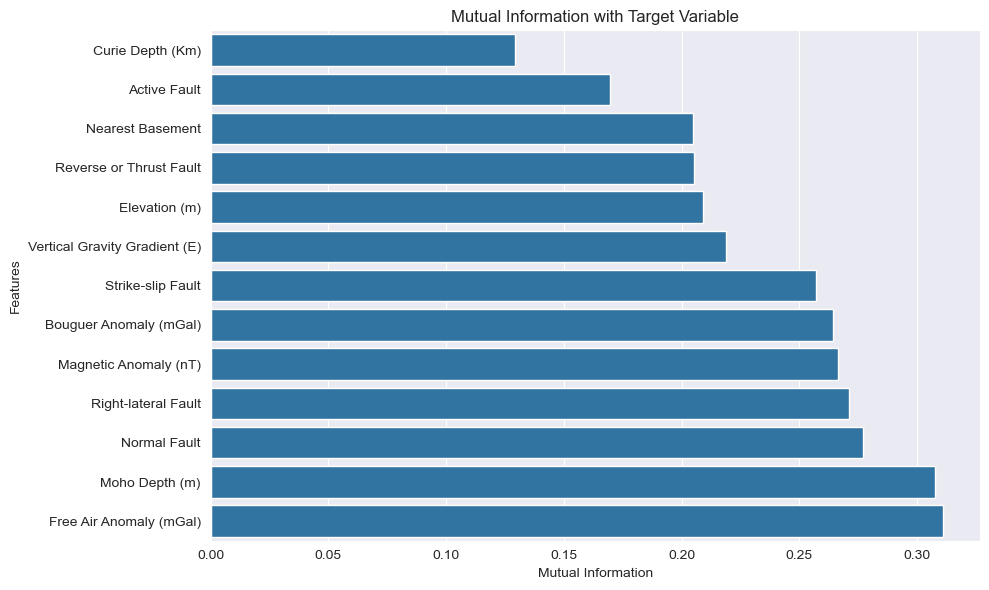

In [44]:
# Compute Mutual Information
mi = mutual_info_regression(X_train, y_train)

# Get the sorted indices (from lowest to highest mutual information)
sorted_indices = mi.argsort()

# Use the sorted indices to order the mutual information scores and feature names
sorted_mi = mi[sorted_indices]
sorted_feature_names = X_train.columns[sorted_indices]

# Plot mutual information
plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_mi, y=sorted_feature_names)
plt.title('Mutual Information with Target Variable')
plt.xlabel('Mutual Information')
plt.ylabel('Features')
plt.tight_layout()  # Adjust layout to fit the figure neatly
plt.show()

## Regression results

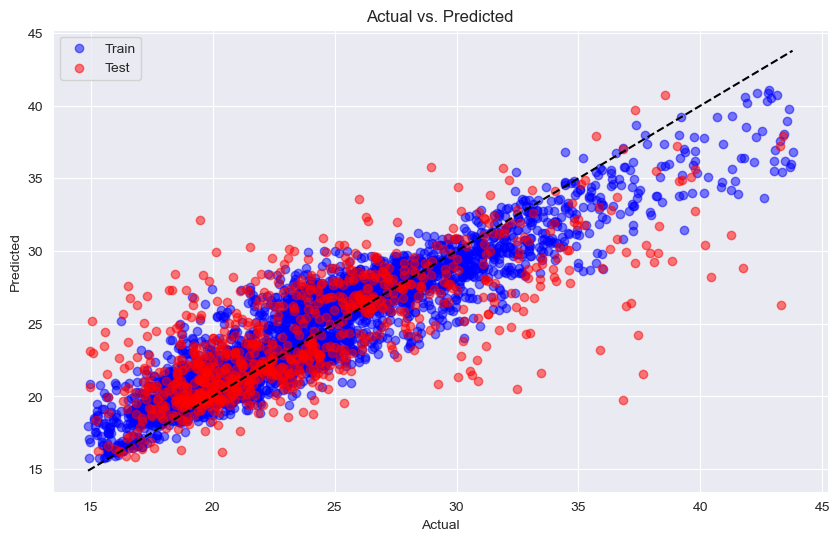

In [45]:
import matplotlib.pyplot as plt

# Use the model to make predictions on the training and test sets
y_train_pred = best_tree_model.predict(X_train)
y_pred = best_tree_model.predict(X_test)

# Create a scatter plot of the actual vs. predicted values for the training set
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, color='blue', label='Train', alpha=0.5)

# Create a scatter plot of the actual vs. predicted values for the test set
plt.scatter(y_test, y_pred, color='red', label='Test', alpha=0.5)

# Plot a line for perfect fit
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--')

# Set the labels and title
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted')
plt.legend()

# Show the plot
plt.show()

## Geospatial visualization

### Actual data

In [46]:
import geopandas as gpd

In [47]:
actual_data = pd.read_csv('normalized_data_minmax.csv')

In [48]:
actual_data.head()

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,Gradient Weight,sample_weight
0,4.216078,-74.888898,0.100557,0.899443,21.294394,0.720455,0.359897,0.053527,0.102362,0.022877,...,0.642857,0.341539,0.096100,0.241172,0.107926,0.034629,True,1,0.025810,0.025810
1,4.214720,-74.891220,0.101535,0.898465,23.783404,0.720641,0.359897,0.054497,0.102794,0.022201,...,0.642857,0.341539,0.096100,0.241172,0.107145,0.034457,True,1,0.025460,0.025460
2,0.606276,-76.564731,0.088329,0.911671,24.156323,0.412171,0.515283,0.121886,0.168226,0.112310,...,0.357143,0.467743,0.319461,0.615321,0.173626,0.081206,False,4,0.025460,0.101840
3,0.305911,-76.914853,0.029052,0.970948,25.601245,0.483869,0.521874,0.126023,0.144177,0.097701,...,0.357143,0.460502,0.316090,0.628522,0.176712,0.093585,False,4,0.030197,0.120787
4,0.287539,-76.911964,0.095470,0.904530,26.559722,0.477817,0.521874,0.130004,0.149747,0.101809,...,0.357143,0.460502,0.360872,0.644461,0.181525,0.095853,False,4,0.043282,0.173128


### Predicted data

In [49]:
# Make predictions using the entire dataset (X)
y_pred_full = best_tree_model.predict(X)

# Update your existing DataFrame or create a new one to store the predictions
X_lat_lon['Predicted Geothermal Gradient (°C/Km)'] = y_pred_full

In [50]:
X_lat_lon.head()

,Latitude,Longitude,Predicted Geothermal Gradient (°C/Km)
0,4.216078,-74.888898,23.234775
1,4.214720,-74.891220,23.762046
2,0.606276,-76.564731,25.943278
3,0.305911,-76.914853,25.430344
4,0.287539,-76.911964,26.875507


In [51]:
X_lat_lon.to_csv('predicted_dataset.csv', index=False)

In [52]:
X_lat_lon = pd.read_csv('predicted_dataset.csv')

### Plot actual and predicted

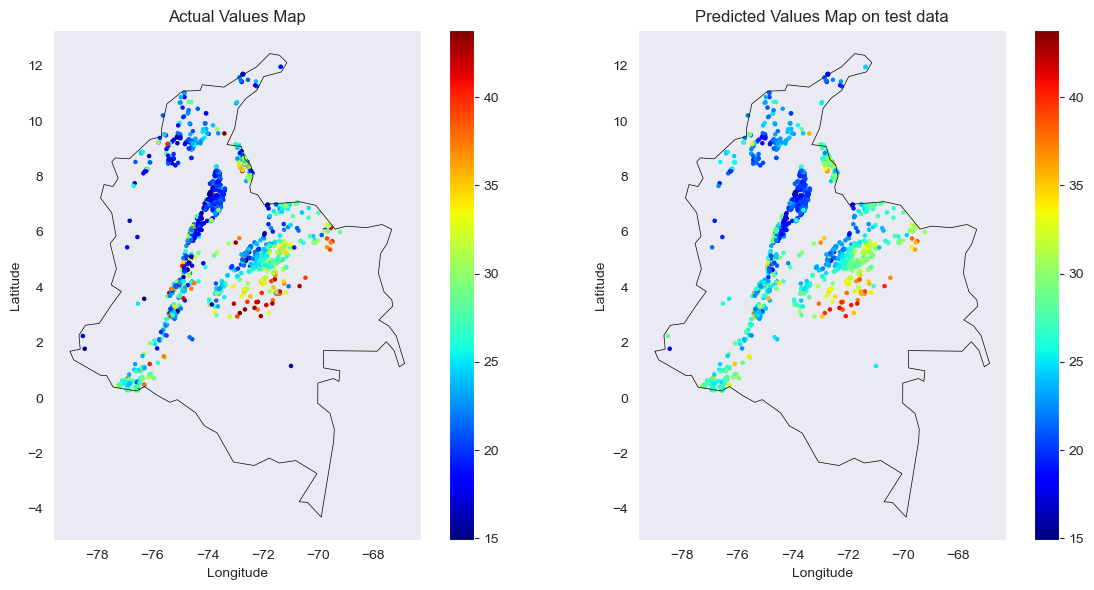

In [53]:
# Load GeoDataFrame for actual values
actual_gdf = gpd.GeoDataFrame(actual_data, geometry=gpd.points_from_xy(actual_data['Longitude'], actual_data['Latitude']))

# Load GeoDataFrame for predicted values
predicted_gdf = gpd.GeoDataFrame(X_lat_lon, geometry=gpd.points_from_xy(X_lat_lon['Longitude'], X_lat_lon['Latitude']))

# Determine the common color range
vmin = min(actual_gdf['Apparent Geothermal Gradient (°C/Km)'].min(), predicted_gdf['Predicted Geothermal Gradient (°C/Km)'].min())
vmax = max(actual_gdf['Apparent Geothermal Gradient (°C/Km)'].max(), predicted_gdf['Predicted Geothermal Gradient (°C/Km)'].max())

# Create subplots with two axes
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

cmap = 'jet'

# Plot actual values on the first subplot
actual_plot = actual_gdf.plot(column='Apparent Geothermal Gradient (°C/Km)', cmap=cmap, markersize=5, legend=True, ax=axes[0], vmin=vmin, vmax=vmax)
axes[0].set_title('Actual Values Map')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Plot predicted values on the second subplot
predicted_plot = predicted_gdf.plot(column='Predicted Geothermal Gradient (°C/Km)', cmap=cmap, markersize=5, legend=True, ax=axes[1], vmin=vmin, vmax=vmax)
axes[1].set_title('Predicted Values Map on test data')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

# Calculate grid positions based on min and max latitude and longitude
min_lon, max_lon = -78, -66
min_lat, max_lat = -4, 12
lon_grid = list(range(int(min_lon), int(max_lon) + 1, 2))
lat_grid = list(range(int(min_lat), int(max_lat) + 1, 2))

# Add gridlines for lat and lon to both subplots
for ax in axes:
    ax.set_xticks(lon_grid)
    ax.set_yticks(lat_grid)
    ax.grid()

# Load world country geometries
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Subset the world dataset to only include countries within your area of interest
#world = world.cx[-74:-73, 4:5]

import geopandas as gpd
import matplotlib.pyplot as plt

# read low-res Natural Earth "Admin 0 – Countries" (110m) from NACIS CDN
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)   # works directly with the zipped shapefile

# subset to your bbox (lon_min:lon_max, lat_min:lat_max)
world = world.cx[-74:-73, 4:5]

# Plot country borders within your area of interest for both subplots
for ax in axes:
    world.boundary.plot(ax=ax, linewidth=0.5, color='black')

# Show the combined plot with both subplots
plt.tight_layout()
plt.show()


### Difference between actual and predicted

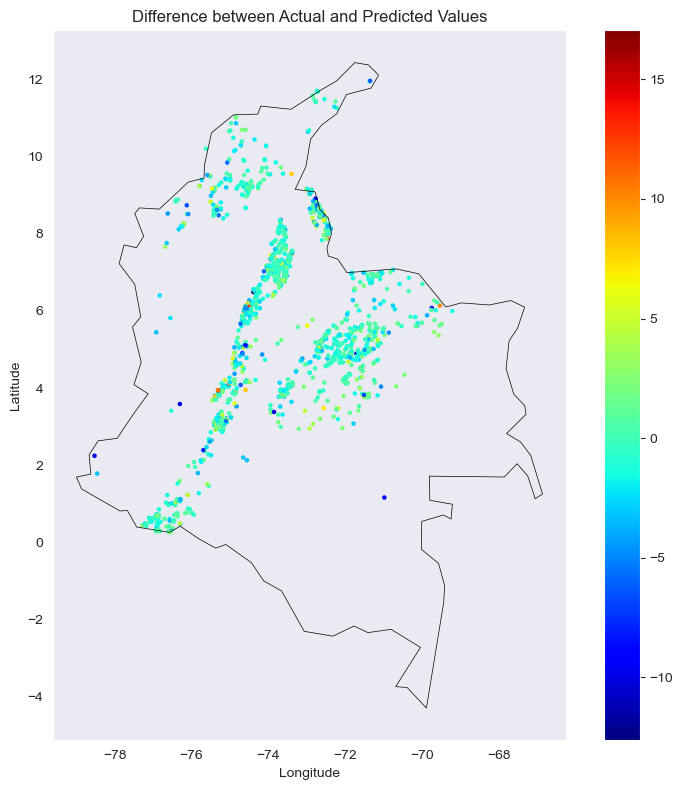

In [54]:
# Calculate the difference between actual and predicted values
actual_gdf['Apparent Geothermal Gradient (°C/Km)'] = actual_gdf['Apparent Geothermal Gradient (°C/Km)'] - predicted_gdf['Predicted Geothermal Gradient (°C/Km)']

# Create a plot for the difference values
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
difference_plot = actual_gdf.plot(column='Apparent Geothermal Gradient (°C/Km)', cmap=cmap, markersize=5, legend=True, ax=ax)
ax.set_title('Difference between Actual and Predicted Values')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Calculate grid positions based on min and max latitude and longitude
min_lon, max_lon = -78, -66
min_lat, max_lat = -4, 12
lon_grid = list(range(int(min_lon), int(max_lon) + 1, 2))
lat_grid = list(range(int(min_lat), int(max_lat) + 1, 2))

# Add gridlines for lat and lon
ax.set_xticks(lon_grid)
ax.set_yticks(lat_grid)
ax.grid()

# Load world country geometries
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Subset the world dataset to only include countries within your area of interest
#world = world.cx[-74:-73, 4:5]


#Prueba
# read low-res Natural Earth "Admin 0 – Countries" (110m) from NACIS CDN
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)   # works directly with the zipped shapefile

# subset to your bbox (lon_min:lon_max, lat_min:lat_max)
world = world.cx[-74:-73, 4:5]

# Plot country borders within your area of interest
world.boundary.plot(ax=ax, linewidth=0.5, color='black')

# Show the plot
plt.tight_layout()
plt.show()


## Feature influence

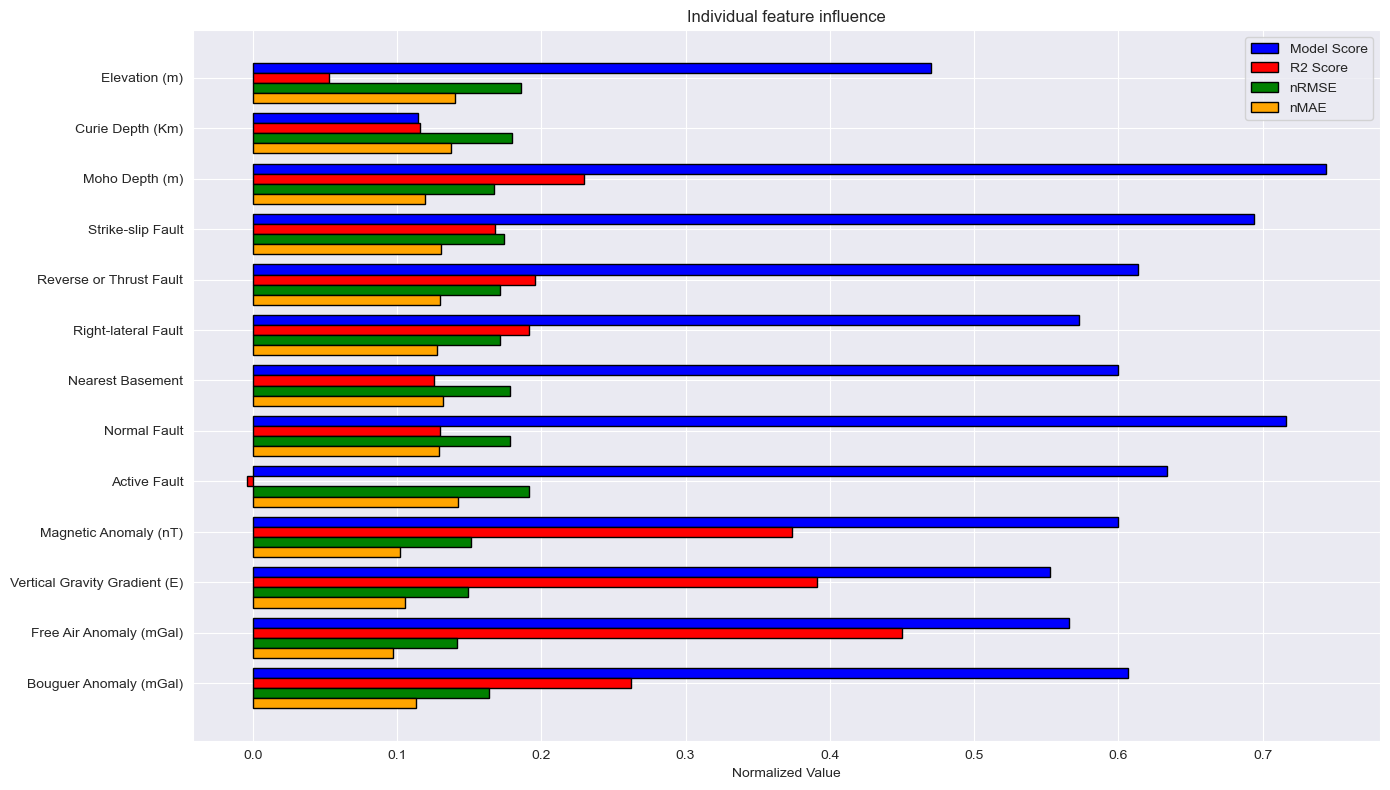

In [60]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Initialize lists to store results
features = []
training_scores = []
test_scores = []
nRMSEs = []
nMAEs = []

# Iterate over each feature in the dataset
for feature in X_train.columns:
    # Train the model using only this feature
    best_tree_model.fit(X_train[[feature]], y_train)
    
    # Calculate the training score (model score)
    training_score = best_tree_model.score(X_train[[feature]], y_train)
    training_scores.append(training_score)
    
    # Use the model to make predictions on the test set
    predictions = best_tree_model.predict(X_test[[feature]])
    
    # Calculate the test score (R2 score)
    test_score = r2_score(y_test, predictions)
    test_scores.append(test_score)
    
    # Calculate the normalized Root Mean Square Error (nRMSE)
    nRMSE = np.sqrt(mean_squared_error(y_test, predictions)) / (y_test.max() - y_test.min())
    nRMSEs.append(nRMSE)
    
    # Calculate the normalized Mean Absolute Error (nMAE)
    nMAE = mean_absolute_error(y_test, predictions) / (y_test.max() - y_test.min())
    nMAEs.append(nMAE)
    
    # Store the feature name
    features.append(feature)

# Plot the results
plt.figure(figsize=(14, 8))
y_pos = np.arange(len(features))
bar_width = 0.2

# Plot each metric
plt.barh(y_pos, training_scores, bar_width, label='Model Score', color='b', edgecolor='black')
plt.barh(y_pos + bar_width, test_scores, bar_width, label='R2 Score', color='r', edgecolor='black')
plt.barh(y_pos + 2*bar_width, nRMSEs, bar_width, label='nRMSE', color='g', edgecolor='black')
plt.barh(y_pos + 3*bar_width, nMAEs, bar_width, label='nMAE', color='orange', edgecolor='black')

# Label axes and title
plt.xlabel('Normalized Value')
plt.yticks(y_pos + bar_width, features)
plt.title('Individual feature influence')
plt.legend()

# Display the plot
plt.gca().invert_yaxis()  # To display the highest importance at the top
plt.tight_layout()
plt.show()

In [61]:
best_tree_model = joblib.load('trained_model_randforest_v3.pkl')

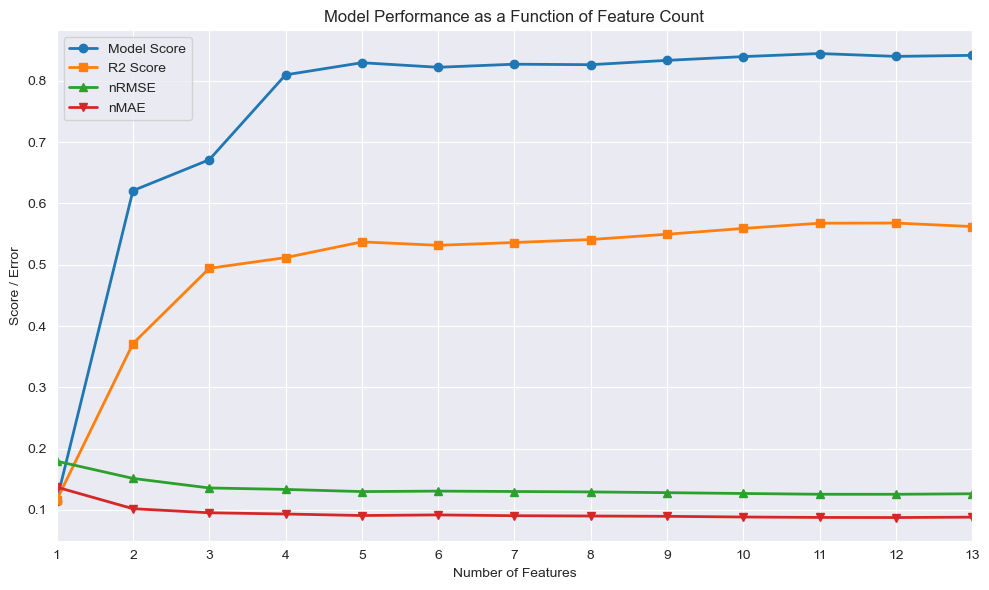

In [62]:
# Obtener importancia de características del Random Forest
importance = best_tree_model.feature_importances_

# Normalizar igual que hacías con XGBoost
importance_norm = importance / np.max(importance)

# Crear diccionario nombre → importancia
importance_dict = dict(zip(X_train.columns, importance_norm))

# Ordenar de menor a mayor (igual que tu sorted(reverse=False))
sorted_features = sorted(importance_dict, key=importance_dict.get, reverse=False)

# El resto del código funciona igual
num_features = []
training_scores = []
test_scores = []
nRMSEs = []
nMAEs = []

for i in range(len(sorted_features)):
    current_features = sorted_features[:i+1]

    best_tree_model.fit(X_train[current_features], y_train)

    training_score = best_tree_model.score(X_train[current_features], y_train)
    training_scores.append(training_score)

    predictions = best_tree_model.predict(X_test[current_features])

    test_score = r2_score(y_test, predictions)
    test_scores.append(test_score)

    nRMSE = np.sqrt(mean_squared_error(y_test, predictions)) / (y_test.max() - y_test.min())
    nRMSEs.append(nRMSE)

    nMAE = mean_absolute_error(y_test, predictions) / (y_test.max() - y_test.min())
    nMAEs.append(nMAE)

    num_features.append(i+1)

# Gráfica
plt.figure(figsize=(10, 6))
plt.plot(num_features, training_scores, label='Model Score', linewidth=2, marker='o')
plt.plot(num_features, test_scores, label='R2 Score', linewidth=2, marker='s')
plt.plot(num_features, nRMSEs, label='nRMSE', linewidth=2, marker='^')
plt.plot(num_features, nMAEs, label='nMAE', linewidth=2, marker='v')

plt.title('Model Performance as a Function of Feature Count')
plt.xlabel('Number of Features')
plt.ylabel('Score / Error')
plt.xticks(range(1, len(sorted_features) + 1))
plt.grid(True)
plt.legend()

plt.xlim(1, len(sorted_features))
plt.tight_layout()
plt.show()


## Load the model again

This is done as the feature influence modifies the model

In [63]:
best_tree_model = joblib.load('trained_model_randforest_v3.pkl')

# Predicting new values (Colombia)

We'll use a Colombia Cities Database to extract latitude and longitude data for the whole country (over 9000 geographic points)

In [64]:
points = pd.read_csv('full_prediction_points.csv')
points.head()

,Longitude,Latitude,Elevation (m),Moho Depth (m),Magnetic Anomaly (nT),Curie Depth (Km),Free Air Anomaly (mGal),Vertical Gravity Gradient (E),Bouguer Anomaly (mGal),Fault,Strike-slip Fault,Reverse or Thrust Fault,Lineament,Right-lateral Fault,Normal Fault,Active Fault
0,-74.794856,0.111833,200.784314,32488.915931,3.8230,28.0,3.975006,-6.90625,-17.508859,178037.951681,266150.917578,163068.133388,30656.334101,188690.916796,430739.458416,183732.387871
1,-68.287650,4.736540,100.392157,36850.416579,16.6622,26.0,-11.250000,5.96875,-26.920581,151452.199487,115825.817422,420132.277124,150902.349172,115369.699200,331587.680042,185087.024128
2,-71.942279,2.436080,175.686275,34514.711131,56.4549,34.0,34.674988,2.71875,11.945339,80530.518451,213884.781245,208196.191584,71601.546101,226367.196923,289049.528767,210198.069559
3,-72.123881,-0.423472,175.686275,32634.499120,-55.9045,32.0,40.649994,5.68750,16.889133,327542.462253,393735.137355,364979.069775,41900.659459,412998.573631,603087.057378,354447.266166
4,-74.030652,9.612854,75.294118,39241.111397,-13.7271,24.0,-41.274994,-6.53125,-58.585397,40206.430428,25547.367278,39226.312282,129419.831964,67022.325909,298598.932464,33344.959873


## Add distance to nearest basement (surface)

In [65]:
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm

gdf_points = gpd.GeoDataFrame(
    points,
    geometry=gpd.points_from_xy(points.Longitude, points.Latitude),
    crs="EPSG:4326"  # WGS84
)

# Load the 'basement' shapefile
basement = gpd.read_file('data/Geology/Rock_types.shx')

# Filter 'basement' to only include rows where 'classified' equals 1
basement_classified_1 = basement[basement['classified'] == 1]

# Reproject both GeoDataFrames to MAGNA-SIRGAS (EPSG:3116)
gdf_cleaned_data = gdf_cleaned_data.to_crs("EPSG:3116")
basement_classified_1 = basement_classified_1.to_crs("EPSG:3116")

# Initialize a column for the distances
points['Nearest Basement'] = np.nan

# Calculate the distance from each point in 'gdf_cleaned_data' to the nearest '1' in 'basement_classified_1'
for index, row in tqdm(gdf_cleaned_data.iterrows(), total=gdf_cleaned_data.shape[0], desc="Calculating distances"):
    # Calculate the distance to the nearest point in 'basement_classified_1' and update the 'distance_to_1' column
    points.at[index, 'Nearest Basement'] = basement_classified_1.distance(row.geometry).min()

Calculating distances: 100%|██████████| 4543/4543 [01:16<00:00, 59.28it/s]


In [66]:
points.head()

,Longitude,Latitude,Elevation (m),Moho Depth (m),Magnetic Anomaly (nT),Curie Depth (Km),Free Air Anomaly (mGal),Vertical Gravity Gradient (E),Bouguer Anomaly (mGal),Fault,Strike-slip Fault,Reverse or Thrust Fault,Lineament,Right-lateral Fault,Normal Fault,Active Fault,Nearest Basement
0,-74.794856,0.111833,200.784314,32488.915931,3.8230,28.0,3.975006,-6.90625,-17.508859,178037.951681,266150.917578,163068.133388,30656.334101,188690.916796,430739.458416,183732.387871,26430.359640
1,-68.287650,4.736540,100.392157,36850.416579,16.6622,26.0,-11.250000,5.96875,-26.920581,151452.199487,115825.817422,420132.277124,150902.349172,115369.699200,331587.680042,185087.024128,26807.505168
2,-71.942279,2.436080,175.686275,34514.711131,56.4549,34.0,34.674988,2.71875,11.945339,80530.518451,213884.781245,208196.191584,71601.546101,226367.196923,289049.528767,210198.069559,26613.393422
3,-72.123881,-0.423472,175.686275,32634.499120,-55.9045,32.0,40.649994,5.68750,16.889133,327542.462253,393735.137355,364979.069775,41900.659459,412998.573631,603087.057378,354447.266166,43126.506306
4,-74.030652,9.612854,75.294118,39241.111397,-13.7271,24.0,-41.274994,-6.53125,-58.585397,40206.430428,25547.367278,39226.312282,129419.831964,67022.325909,298598.932464,33344.959873,43893.018161


## Normalization

In [68]:
from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = ['Elevation (m)', 'Moho Depth (m)', 
       'Curie Depth (Km)', 'Fault', 'Strike-slip Fault',
       'Reverse or Thrust Fault', 'Lineament', 'Right-lateral Fault',
       'Normal Fault', 'Active Fault', 'Magnetic Anomaly (nT)',
       'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)',
       'Bouguer Anomaly (mGal)', 'Nearest Basement']

# Initialize the Min-Max scaler
scaler = MinMaxScaler()

# Fit and transform the selected columns
points[columns_to_normalize] = scaler.fit_transform(points[columns_to_normalize])

# Save the normalized data to a new CSV file
points.to_csv('normalized_full_prediction.csv', index=False)

In [69]:
points = pd.read_csv('normalized_full_prediction.csv')
points.head()

,Longitude,Latitude,Elevation (m),Moho Depth (m),Magnetic Anomaly (nT),Curie Depth (Km),Free Air Anomaly (mGal),Vertical Gravity Gradient (E),Bouguer Anomaly (mGal),Fault,Strike-slip Fault,Reverse or Thrust Fault,Lineament,Right-lateral Fault,Normal Fault,Active Fault,Nearest Basement
0,-74.794856,0.111833,0.042328,0.285085,0.604210,0.642857,0.139375,0.251871,0.397807,0.266546,0.308912,0.196042,0.075754,0.214496,0.428156,0.264893,0.106408
1,-68.287650,4.736540,0.021164,0.444411,0.645887,0.571429,0.124705,0.264107,0.383486,0.226731,0.133889,0.505402,0.383612,0.131062,0.329133,0.266846,0.107926
2,-71.942279,2.436080,0.037037,0.359088,0.775058,0.857143,0.168955,0.261018,0.442627,0.120519,0.248059,0.250351,0.180583,0.257368,0.286651,0.303053,0.107145
3,-72.123881,-0.423472,0.037037,0.290403,0.410328,0.785714,0.174712,0.263839,0.450150,0.490443,0.457458,0.439029,0.104542,0.469740,0.600280,0.511041,0.173626
4,-74.030652,9.612854,0.015873,0.531744,0.547240,0.500000,0.095775,0.252227,0.335302,0.060130,0.028778,0.047006,0.328612,0.076047,0.296188,0.048054,0.176712


## Prediction

In [70]:
selected_features = ['Elevation (m)',
       'Curie Depth (Km)','Moho Depth (m)', 
       'Strike-slip Fault', 'Reverse or Thrust Fault', 
       'Right-lateral Fault', 'Nearest Basement',
       'Normal Fault', 'Active Fault','Magnetic Anomaly (nT)',
       'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)',
       'Bouguer Anomaly (mGal)']

# Create a new DataFrame with the selected columns
selected_data = points[selected_features]

X_new = selected_data.values  # Convert the DataFrame to a 2D numpy array

# Use the XGBoost model to make predictions
y_pred_new = best_tree_model.predict(X_new)

# Add the predicted values to the points DataFrame
points['Predicted Geothermal Gradient (°C/Km)'] = y_pred_new


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [71]:
predicted_new = points

In [72]:
points.to_csv('predicted_new_random_forest.csv', index=False)

In [73]:
predicted_new = pd.read_csv('predicted_new_random_forest.csv')
predicted_new.head()

,Longitude,Latitude,Elevation (m),Moho Depth (m),Magnetic Anomaly (nT),Curie Depth (Km),Free Air Anomaly (mGal),Vertical Gravity Gradient (E),Bouguer Anomaly (mGal),Fault,Strike-slip Fault,Reverse or Thrust Fault,Lineament,Right-lateral Fault,Normal Fault,Active Fault,Nearest Basement,Predicted Geothermal Gradient (°C/Km)
0,-74.794856,0.111833,0.042328,0.285085,0.604210,0.642857,0.139375,0.251871,0.397807,0.266546,0.308912,0.196042,0.075754,0.214496,0.428156,0.264893,0.106408,26.642076
1,-68.287650,4.736540,0.021164,0.444411,0.645887,0.571429,0.124705,0.264107,0.383486,0.226731,0.133889,0.505402,0.383612,0.131062,0.329133,0.266846,0.107926,27.000049
2,-71.942279,2.436080,0.037037,0.359088,0.775058,0.857143,0.168955,0.261018,0.442627,0.120519,0.248059,0.250351,0.180583,0.257368,0.286651,0.303053,0.107145,27.751796
3,-72.123881,-0.423472,0.037037,0.290403,0.410328,0.785714,0.174712,0.263839,0.450150,0.490443,0.457458,0.439029,0.104542,0.469740,0.600280,0.511041,0.173626,31.333460
4,-74.030652,9.612854,0.015873,0.531744,0.547240,0.500000,0.095775,0.252227,0.335302,0.060130,0.028778,0.047006,0.328612,0.076047,0.296188,0.048054,0.176712,25.248800


<Axes: xlabel='Predicted Geothermal Gradient (°C/Km)', ylabel='Count'>

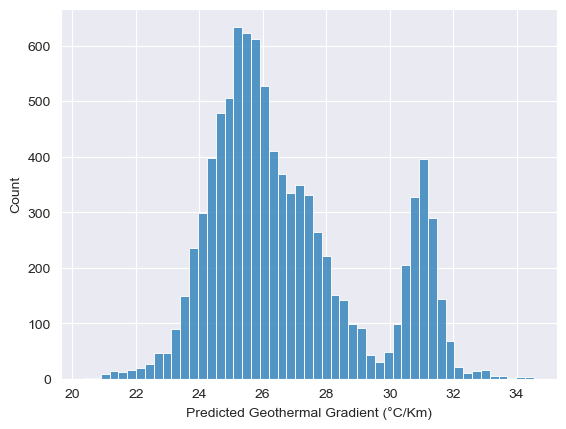

In [74]:
sns.histplot(predicted_new['Predicted Geothermal Gradient (°C/Km)'], kde=False)

### Plot map

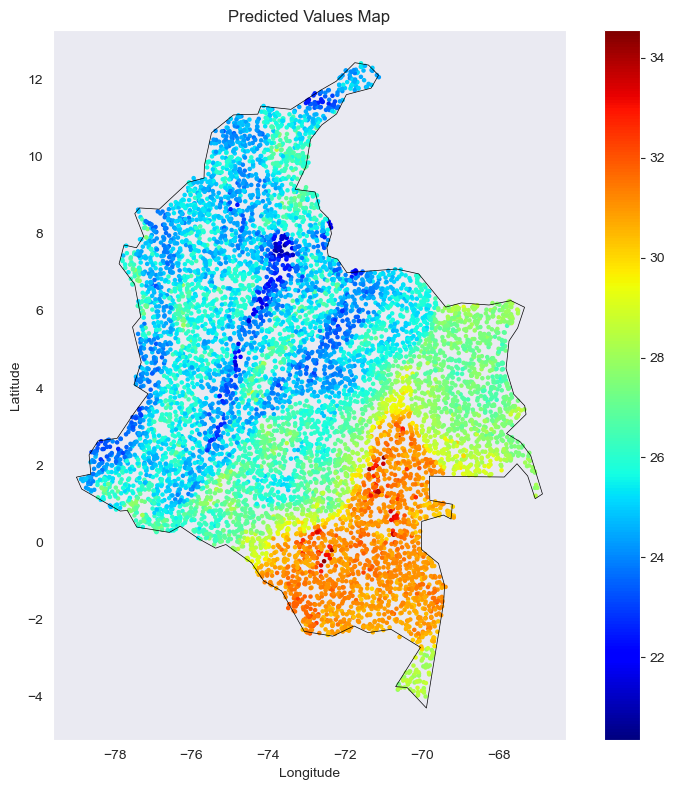

In [75]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load the GeoDataFrame for predicted values
predicted_gdf = gpd.GeoDataFrame(predicted_new, geometry=gpd.points_from_xy(predicted_new['Longitude'], predicted_new['Latitude']))

# Determine the color range
vmin = predicted_gdf['Predicted Geothermal Gradient (°C/Km)'].min()
vmax = predicted_gdf['Predicted Geothermal Gradient (°C/Km)'].max()

# Create a subplot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the predicted values
predicted_plot = predicted_gdf.plot(column='Predicted Geothermal Gradient (°C/Km)', cmap=cmap, markersize=5, legend=True, ax=ax)
ax.set_title('Predicted Values Map')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Calculate grid positions based on your data's latitude and longitude
min_lon, max_lon = -78, -66
min_lat, max_lat = -4, 12
lon_grid = list(range(int(min_lon), int(max_lon) + 1, 2))
lat_grid = list(range(int(min_lat), int(max_lat) + 1, 2))

# Add gridlines for latitude and longitude
ax.set_xticks(lon_grid)
ax.set_yticks(lat_grid)
ax.grid()

# Load world country geometries
#world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Subset the world dataset to only include countries within your area of interest
#world = world.cx[-74:-73, 4:5]

# read low-res Natural Earth "Admin 0 – Countries" (110m) from NACIS CDN
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)   # works directly with the zipped shapefile

# subset to your bbox (lon_min:lon_max, lat_min:lat_max)
world = world.cx[-74:-73, 4:5]

# Plot country borders within your area of interest
world.boundary.plot(ax=ax, linewidth=0.5, color='black')

# Show the plot
plt.tight_layout()
plt.show()